-> Archivo CSV guardado con éxito en:
   C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\figuras\Espectro_Objetivo_Neiva_Roca.csv
-> Figura PNG guardada con éxito en:
   C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\figuras\Espectro_Objetivo_Neiva_Roca.png


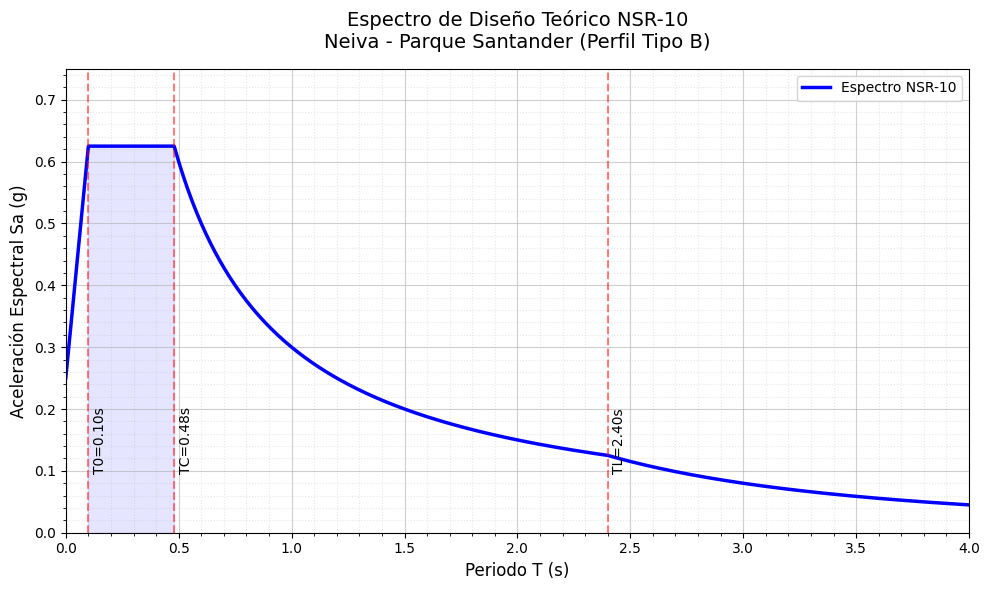

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# 0. Definición y Creación de la Ruta de Salida
# ==========================================
ruta_destino = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\figuras"

# Crear la carpeta en caso de que no exista previamente
os.makedirs(ruta_destino, exist_ok=True)

# ==========================================
# 1. Parámetros de Amenaza y Sitio (NSR-10)
# Ubicación: Neiva, Huila (Parque Santander)
# Suelo: Perfil Tipo B (Roca)
# ==========================================
Aa = 0.25   # Aceleración pico efectiva
Av = 0.25   # Velocidad pico efectiva
Fa = 1.0    # Coeficiente de amplificación en periodo corto (Roca)
Fv = 1.0    # Coeficiente de amplificación en periodos intermedios (Roca)
I = 1.0     # Coeficiente de importancia (Grupo I)

# ==========================================
# 2. Cálculo de Periodos de Control (Segundos)
# ==========================================
T0 = 0.1 * (Av * Fv) / (Aa * Fa)   # Periodo inicial de la meseta (0.10 s)
TC = 0.48 * (Av * Fv) / (Aa * Fa)  # Periodo final de la meseta (0.48 s)
TL = 2.4 * Fv                      # Periodo de inicio zona de desp. constante (2.40 s)

# ==========================================
# 3. Vector de Periodos (0 a 4 segundos)
# ==========================================
T = np.arange(0.0, 4.01, 0.01)
Sa = np.zeros_like(T)

# ==========================================
# 4. Cálculo del Espectro Elástico
# ==========================================
for i, t in enumerate(T):
    if t < T0:
        Sa[i] = 2.5 * Aa * Fa * I * (0.4 + 0.6 * (t / T0))
    elif t <= TC:
        Sa[i] = 2.5 * Aa * Fa * I
    elif t <= TL:
        Sa[i] = (1.2 * Av * Fv * I) / t
    else:
        Sa[i] = (1.2 * Av * Fv * TL * I) / (t**2)

# ==========================================
# 5. Exportar a CSV para PEER
# ==========================================
df = pd.DataFrame({'Period(s)': T, 'Sa(g)': Sa})
ruta_csv = os.path.join(ruta_destino, 'Espectro_Objetivo_Neiva_Roca.csv')
df.to_csv(ruta_csv, index=False)
print(f"-> Archivo CSV guardado con éxito en:\n   {ruta_csv}")

# ==========================================
# 6. Graficar y Guardar la Figura
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(T, Sa, color='blue', linewidth=2.5, label='Espectro NSR-10')

# Rellenar la zona de la meseta
T_meseta = T[(T >= T0) & (T <= TC)]
Sa_meseta = Sa[(T >= T0) & (T <= TC)]
plt.fill_between(T_meseta, Sa_meseta, color='blue', alpha=0.1)

plt.title('Espectro de Diseño Teórico NSR-10\nNeiva - Parque Santander (Perfil Tipo B)', fontsize=14, pad=15)
plt.xlabel('Periodo T (s)', fontsize=12)
plt.ylabel('Aceleración Espectral Sa (g)', fontsize=12)

plt.grid(True, which='major', linestyle='-', alpha=0.6)
plt.grid(True, which='minor', linestyle=':', alpha=0.3)
plt.minorticks_on()
plt.xlim(0, 4)
plt.ylim(0, max(Sa) * 1.2)

# Anotaciones de los puntos clave
plt.axvline(x=T0, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=TC, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=TL, color='r', linestyle='--', alpha=0.5)
plt.text(T0 + 0.02, 0.1, f'T0={T0:.2f}s', rotation=90)
plt.text(TC + 0.02, 0.1, f'TC={TC:.2f}s', rotation=90)
plt.text(TL + 0.02, 0.1, f'TL={TL:.2f}s', rotation=90)

plt.legend()
plt.tight_layout()

# Guardar imagen en alta resolución
ruta_figura = os.path.join(ruta_destino, 'Espectro_Objetivo_Neiva_Roca.png')
plt.savefig(ruta_figura, dpi=300, bbox_inches='tight')
print(f"-> Figura PNG guardada con éxito en:\n   {ruta_figura}")

plt.show()

In [4]:
import os
import urllib.request
from obspy import UTCDateTime, read
from obspy.clients.fdsn import Client

# 1. Directorio de destino indicado
DIRECTORIO_DESTINO = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos sismo\02_Sismos_seleccionados"
os.makedirs(DIRECTORIO_DESTINO, exist_ok=True)

# 2. Lista de sismos extraídos de la tabla del SGC (Tiempos UTC)
SISMOS = [
    {
        "id": "SGC2012mtaftr",
        "lugar": "La Vega - Cauca",
        "utc": "2012-09-30T16:31:34"
    },
    {
        "id": "SGC1997ijtryp",
        "lugar": "Génova - Quindío",
        "utc": "1997-12-11T07:56:29"
    },
    {
        "id": "SGC1997jovadh",
        "lugar": "Roncesvalles - Tolima",
        "utc": "1997-09-02T12:13:21"
    },
    {
        "id": "SGC1995psblpi",
        "lugar": "Risaralda - Caldas",
        "utc": "1995-08-19T21:43:33"
    },
    {
        "id": "SGC2023qdvnvf",
        "lugar": "San Juanito - Meta",
        "utc": "2023-08-17T17:04:51"
    },
    {
        "id": "SGC2019ftmxe",
        "lugar": "Versalles - Valle del Cauca",
        "utc": "2019-03-23T19:21:17"
    },
    {
        "id": "SGC1999yyrtro",
        "lugar": "Córdoba - Quindío",
        "utc": "1999-01-25T18:19:18"
    },
    {
        "id": "SGC2001jotlzk",
        "lugar": "San Pedro - Valle Del Cauca",
        "utc": "2001-09-22T03:23:39"
    }
]

def descargar_sismo(sismo_info):
    codigo_id = sismo_info["id"]
    tiempo_evento = UTCDateTime(sismo_info["utc"])
    
    # Se define una ventana de 1 minuto antes del sismo y 5 minutos después
    t_inicio = tiempo_evento - 60
    t_fin = tiempo_evento + 300
    
    archivo_salida = os.path.join(DIRECTORIO_DESTINO, f"{codigo_id}.mseed")
    print(f"\n==================================================")
    print(f"Procesando: {codigo_id} ({sismo_info['lugar']})")
    print(f"Hora UTC Evento: {sismo_info['utc']}")
    
    # Intento 1: Cliente FDSN de EarthScope / IRIS (Especialmente para sismos recientes y red global)
    try:
        print("  -> Intentando descargar via FDSN EarthScope...")
        client_es = Client("EARTHSCOPE")
        st = client_es.get_waveforms(
            network="CM",
            station="*",
            location="*",
            channel="H*,B*,E*",
            starttime=t_inicio,
            endtime=t_fin
        )
        if len(st) > 0:
            st.write(archivo_salida, format="MSEED")
            print(f"  [ÉXITO] Guardado via EarthScope en:\n  {archivo_salida} ({len(st)} trazas)")
            return
    except Exception as e:
        print(f"  [x] EarthScope no devolvió datos: {e}")

    # Intento 2: Petición HTTP directa al servidor FDSN del SGC (Puerto 8080)
    try:
        print("  -> Intentando petición HTTP directa al servidor SGC (Puerto 8080)...")
        url_sgc = (
            f"http://sismo.sgc.gov.co:8080/fdsnws/dataselect/1/query?"
            f"network=CM&station=*&location=*&channel=*&"
            f"starttime={t_inicio.strftime('%Y-%m-%dT%H:%M:%S')}&"
            f"endtime={t_fin.strftime('%Y-%m-%dT%H:%M:%S')}&"
            f"format=miniseed"
        )
        
        urllib.request.urlretrieve(url_sgc, archivo_salida)
        
        if os.path.exists(archivo_salida) and os.path.getsize(archivo_salida) > 1024:
            st = read(archivo_salida)
            print(f"  [ÉXITO] Guardado via SGC Directo en:\n  {archivo_salida} ({len(st)} trazas)")
            return
        else:
            if os.path.exists(archivo_salida):
                os.remove(archivo_salida)
            print("  [x] El servidor SGC no devolvió trazas continuas FDSN para este rango.")
    except Exception as e:
        print(f"  [x] Error conectando con servidor SGC: {e}")

    print(f"  [NOTA]: Para {codigo_id}, descarga la señal procesada directamente del Catálogo del SGC.")

# Ejecutar iteración sobre todos los sismos
print("INICIANDO DESCARGA EN BATCH DE SISMOS SELECCIONADOS...")
for sismo in SISMOS:
    descargar_sismo(sismo)

print("\n==================================================")
print("PROCESO FINALIZADO.")

INICIANDO DESCARGA EN BATCH DE SISMOS SELECCIONADOS...

Procesando: SGC2012mtaftr (La Vega - Cauca)
Hora UTC Evento: 2012-09-30T16:31:34
  -> Intentando descargar via FDSN EarthScope...
  [x] EarthScope no devolvió datos: No data available for request.
HTTP Status code: 204
Detailed response of server:


  -> Intentando petición HTTP directa al servidor SGC (Puerto 8080)...
  [x] El servidor SGC no devolvió trazas continuas FDSN para este rango.
  [NOTA]: Para SGC2012mtaftr, descarga la señal procesada directamente del Catálogo del SGC.

Procesando: SGC1997ijtryp (Génova - Quindío)
Hora UTC Evento: 1997-12-11T07:56:29
  -> Intentando descargar via FDSN EarthScope...
  [x] EarthScope no devolvió datos: No data available for request.
HTTP Status code: 204
Detailed response of server:


  -> Intentando petición HTTP directa al servidor SGC (Puerto 8080)...
  [x] El servidor SGC no devolvió trazas continuas FDSN para este rango.
  [NOTA]: Para SGC1997ijtryp, descarga la señal procesada dir